In [14]:
from autoencoder import autoencoder, build_autoencoder
import cProfile as profile
import pstats

### Configuration

In [15]:
#'NIST/PIEdataRaw1'
"""
'dataset'                : "NIST/PIEdataRaw1",
        'path_save'              : 'Autoencoder Log/',
        'input_dimension'        : 800
"""
#8192 NIST
#496 oxford
config = {
'files' : {
        'dataset'                : "NIST/PIEdataRaw1",
        'path_save'              : 'Autoencoder Log/',
        'input_dimension'        : 8192
        },
'sweep' : {
        'sweep_name'             : None,
        'activation_possibilty'  : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                        'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                        'Mish', 'Softplus', 'Softsign', 'Tanh'],
        'layer_possibility'      : {'number' : [4],
                                    'size'   : [5,50,75,100],
                                   },
        'search_type'            : 'random_search',
        'search_param'           : ['activation_possibilty','layer_possibility']
        },
'run' : {
        'activation_list'        : ['GELU', 'Softplus', 'GELU'],
        'layer_list'             : [400, 100, 2, 100, 400],
        'layer_number'           : 4
        },
'network' : {
        'output_dimension'       : 2,
        'skip_elements'          : 4,
        'layer_type'             : 'Linear',
        'layer_conv'             : True
        },
'train' : {
        'train_size'             : 0.8,
        'batch_number'           : 1,
        'k-fold'                 : 2, 
        'optimizer'              : 'adam',
        'criterion'              : 'MSELoss',
        'epochs'                 : 1,
        'learning_rate'          : 5e-8,
        }
}

experiment = autoencoder()
model = build_autoencoder

### Run

In [16]:
prof = profile.Profile()
prof.enable()
experiment.run(model, config)
prof.disable()

Fold:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
stats = pstats.Stats(prof).strip_dirs().sort_stats("cumtime")
stats.print_stats(30)

         456324631 function calls (441553644 primitive calls) in 6232.431 seconds

   Ordered by: cumulative time
   List reduced from 632 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000 6232.431 3116.215 interactiveshell.py:3472(run_code)
        2    0.000    0.000 6232.431 3116.215 {built-in method builtins.exec}
        1    0.553    0.553 6232.431 6232.431 103957926.py:3(<module>)
        1   18.203   18.203 6231.878 6231.878 autoencoder.py:511(run)
       40   48.392    1.210 5943.286  148.582 autoencoder.py:378(train_epoch)
  1200000   34.819    0.000 3680.731    0.003 optimizer.py:265(wrapper)
  1200000   17.427    0.000 3540.979    0.003 optimizer.py:29(_use_grad)
  1200000   12.645    0.000 3513.360    0.003 adam.py:108(step)
  1200000    9.566    0.000 3452.620    0.003 adam.py:231(adam)
  1200000 1408.261    0.001 3426.105    0.003 adam.py:300(_single_tensor_adam)
  1200000    7.244    0.000 

### Sweep

In [ ]:
#experiment.sweep("sweep1", 2, model, config)

### Load

Activation list :  ['GELU', 'Softplus', 'GELU']
Layer list :  [2048, 100, 2, 100, 2048]


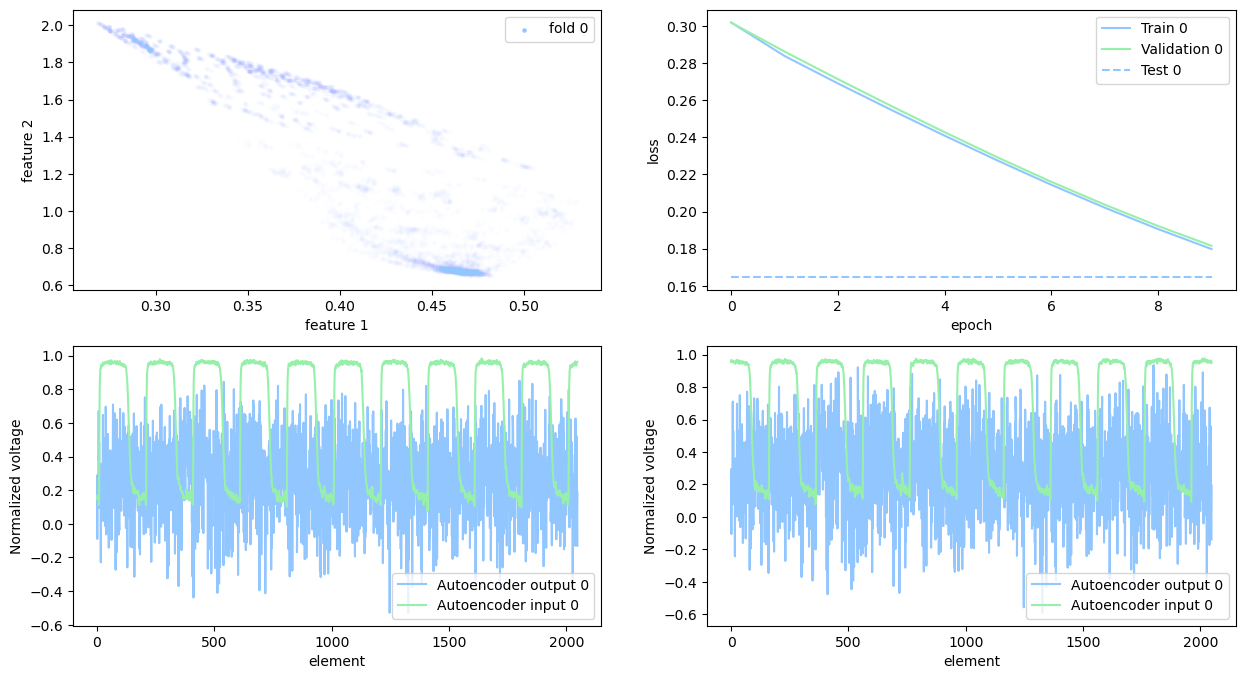

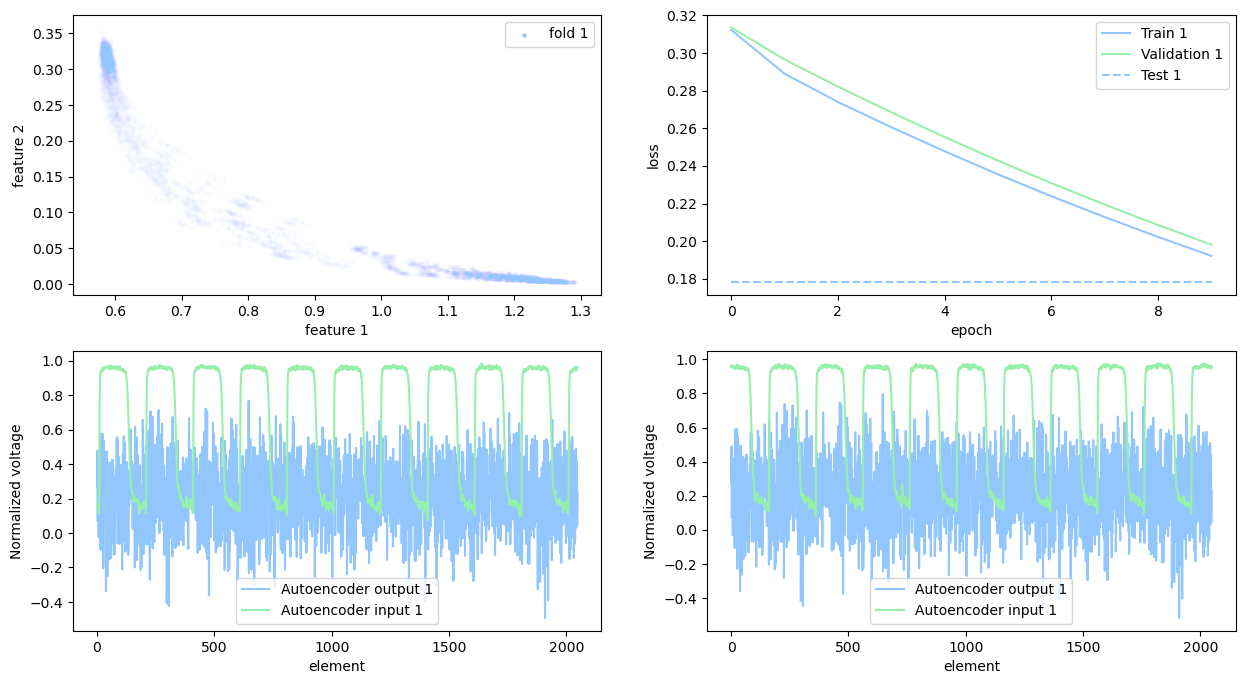

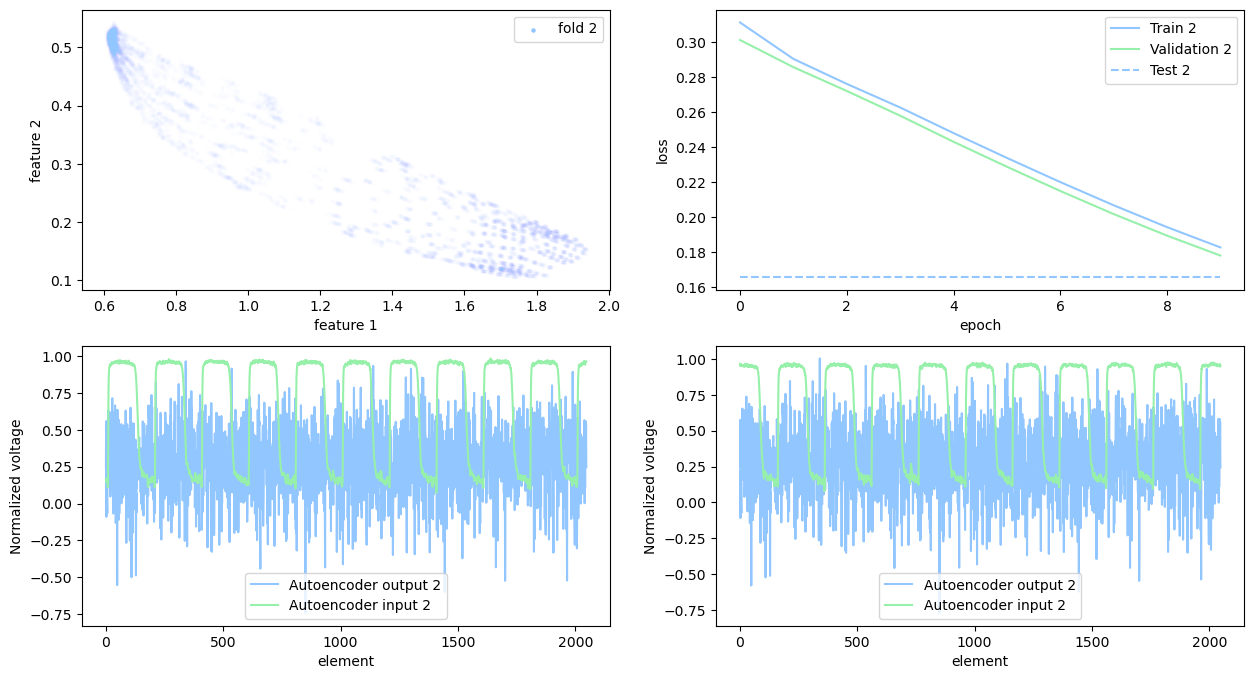

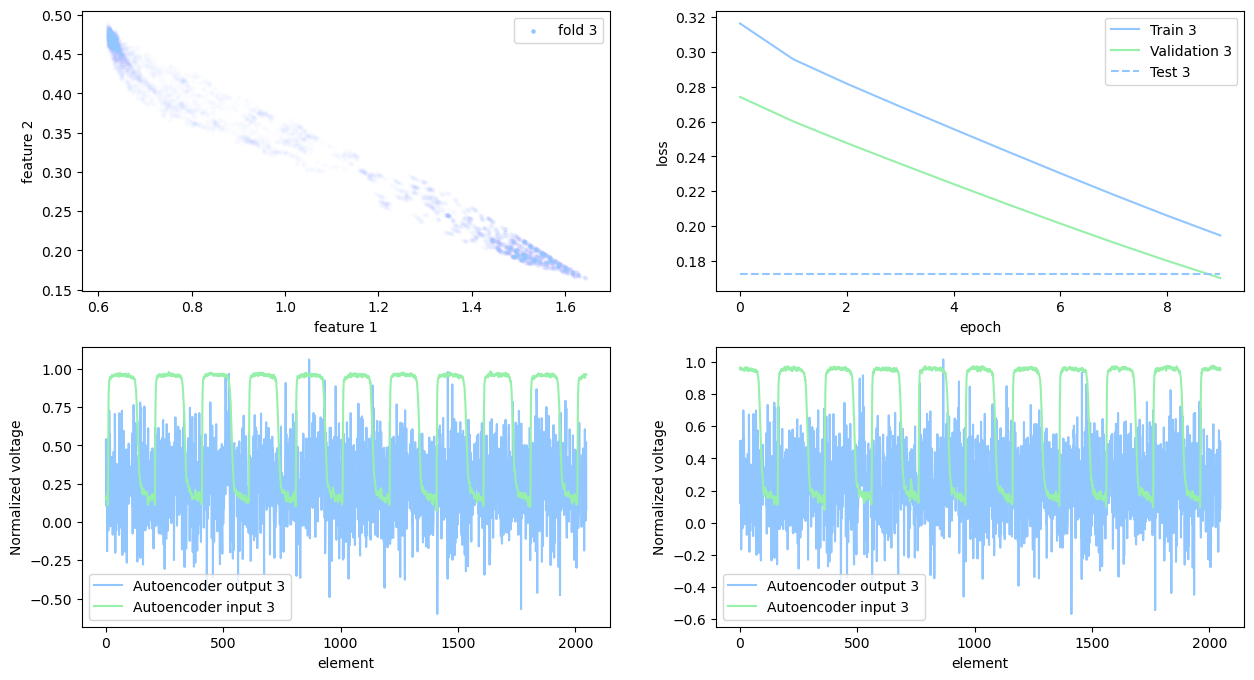

In [ ]:
experiment.load_results("run-2023-06-28-13-51")